# EDA 04 - Darwin Timetable

**Output**: `data/processed/darwin_timetable_clean.parquet`

This notebook prepares Darwin timetable stop rows before exploratory analysis. The workflow is raw load, parser artefact removal, rolling-window duplicate removal, temporal feature preparation, Parquet save and then EDA on the cleaned timetable.

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_04", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./sample_data/processed", exist_ok=True)
%matplotlib inline

## 1. Load and Inspect

In [2]:
from datetime import datetime, timezone
from src.data_loader import load_darwin_timetable

stations_reference_df = pd.read_parquet("./data/processed/stations_reference.parquet")

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 28, 23, 59, 59, tzinfo=timezone.utc)

timetable_df = load_darwin_timetable(START, END)
print(f"Shape: {timetable_df.shape}")
print(f"Columns: {list(timetable_df.columns)}")
print(f"Unique journeys (rid): {timetable_df['rid'].nunique():,}")
timetable_df.head(3)

Shape: (18215990, 14)
Columns: ['rid', 'uid', 'trainId', 'ssd', 'toc', 'stop_type', 'tpl', 'platform', 'act', 'pta', 'ptd', 'wta', 'wtd', 'wtp']
Unique journeys (rid): 633,103


,rid,uid,trainId,ssd,toc,stop_type,tpl,platform,act,pta,ptd,wta,wtd,wtp
0,202604108062281,P62281,2S69,2026-04-10,SW,OR,WATRLMN,18,TB,NaN,21:22,NaN,21:22,NaN
1,202604108062281,P62281,2S69,2026-04-10,SW,PP,WATRLWC,NaN,NaN,NaN,NaN,NaN,NaN,21:23:30
2,202604108062281,P62281,2S69,2026-04-10,SW,IP,VAUXHLM,NaN,T,21:26,21:26,21:25:30,21:26:30,NaN


## 2. Data preprocessing, deduplication and Parquet save

Darwin timetable files are rolling four-day snapshots. When consecutive files are concatenated, the same planned stop appears again in the overlap window. The stop-level duplicate key is `rid`, `tpl`, `stop_type`, `wta`, `wtd` and `wtp`.

`rid` and `tpl` alone are not sufficient because a calling point may contain both a working arrival and a working departure. The working time fields distinguish the stop event precisely enough for this EDA.


In [3]:
timetable_raw_df = timetable_df.copy()

# Drop parser artefacts before checking for timetable duplicates.
if "stop_type" in timetable_raw_df.columns:
    before_invalid = len(timetable_raw_df)
    timetable_raw_df = timetable_raw_df[timetable_raw_df["stop_type"] != "cancelReason"].copy()
    print(f"Invalid stop_type rows removed: {before_invalid - len(timetable_raw_df):,}")

# Rolling Darwin snapshots repeat the same planned stop across files.
dedup_key = [c for c in ["rid", "tpl", "stop_type", "wta", "wtd", "wtp"] if c in timetable_raw_df.columns]
sort_cols = [c for c in ["source_file", "ssd", "rid", "tpl"] if c in timetable_raw_df.columns]
before_dedup = len(timetable_raw_df)
timetable_clean = (
    timetable_raw_df
    .sort_values(sort_cols if sort_cols else dedup_key)
    .drop_duplicates(subset=dedup_key, keep="first")
    .copy()
)
print(f"Duplicate timetable stop rows removed: {before_dedup - len(timetable_clean):,}")

def parse_hhmm(value):
    """Extract the hour from a working time string."""
    try:
        parts = str(value).strip().split(":")
        if len(parts) >= 2:
            return int(parts[0])
    except Exception:
        return None
    return None

if "ssd" in timetable_clean.columns:
    timetable_clean["planned_date"] = pd.to_datetime(timetable_clean["ssd"])
    timetable_clean["day_of_week"] = timetable_clean["planned_date"].dt.dayofweek
    timetable_clean["is_weekend"] = timetable_clean["day_of_week"].isin([5, 6]).astype(int)
    timetable_clean["is_monday"] = (timetable_clean["day_of_week"] == 0).astype(int)
    timetable_clean["is_friday"] = (timetable_clean["day_of_week"] == 4).astype(int)

# Departure time is preferred because it is present for most calling points.
time_col = "wtd" if "wtd" in timetable_clean.columns else "wta"
timetable_clean["sched_hour"] = timetable_clean[time_col].apply(parse_hhmm)
timetable_clean["is_peak"] = timetable_clean["sched_hour"].apply(
    lambda h: 1 if h is not None and (7 <= h <= 9 or 17 <= h <= 19) else 0
)

timetable_clean.to_parquet("./data/processed/darwin_timetable_clean.parquet", index=False)
timetable_clean.to_csv("./sample_data/processed/darwin_timetable_clean.csv", index=False)   
# Use the cleaned dataframe for all EDA cells below.
timetable_df = timetable_clean.copy()

print(f"Clean timetable rows saved: {len(timetable_df):,}")
print(f"Unique journeys:           {timetable_df['rid'].nunique():,}")
print(f"Deduplication key:         {dedup_key}")


Invalid stop_type rows removed: 868
Duplicate timetable stop rows removed: 8,191,659
Clean timetable rows saved: 10,023,463
Unique journeys:           633,103
Deduplication key:         ['rid', 'tpl', 'stop_type', 'wta', 'wtd', 'wtp']


In [4]:

print("Darwin Timetable Range:", timetable_df["planned_date"].min(), "to", timetable_df["planned_date"].max())

Darwin Timetable Range: 2026-04-09 00:00:00 to 2026-04-30 00:00:00


### Data Types and Basic Statistics

In [5]:
timetable_df.info()

<class 'pandas.DataFrame'>
Index: 10023463 entries, 956632 to 18105039
Data columns (total 21 columns):
 #   Column        Dtype        
---  ------        -----        
 0   rid           str          
 1   uid           str          
 2   trainId       str          
 3   ssd           object       
 4   toc           str          
 5   stop_type     str          
 6   tpl           str          
 7   platform      str          
 8   act           str          
 9   pta           str          
 10  ptd           str          
 11  wta           str          
 12  wtd           str          
 13  wtp           str          
 14  planned_date  datetime64[s]
 15  day_of_week   int32        
 16  is_weekend    int64        
 17  is_monday     int64        
 18  is_friday     int64        
 19  sched_hour    float64      
 20  is_peak       int64        
dtypes: datetime64[s](1), float64(1), int32(1), int64(4), object(1), str(13)
memory usage: 2.1+ GB


In [6]:
timetable_df.describe().round(2)

,planned_date,day_of_week,is_weekend,is_monday,is_friday,sched_hour,is_peak
count,10023463,10023463.00,10023463.00,10023463.00,10023463.00,5345792.00,10023463.00
mean,2026-04-19 13:47:25,2.76,0.24,0.16,0.16,13.81,0.18
min,2026-04-09 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2026-04-15 00:00:00,1.00,0.00,0.00,0.00,9.00,0.00
50%,2026-04-20 00:00:00,3.00,0.00,0.00,0.00,14.00,0.00
75%,2026-04-24 00:00:00,4.00,0.00,0.00,0.00,18.00,0.00
max,2026-04-30 00:00:00,6.00,1.00,1.00,1.00,23.00,1.00
std,NaN,1.95,0.43,0.37,0.37,5.44,0.39


## 3. Missing value audit

This audit is run on the cleaned timetable. Working time fields are the most important because they provide the operational timing used later for schedule alignment. Public time fields are retained for interpretation but are not the main timing fields for this pipeline.

In [7]:
missing = pd.DataFrame({
    "missing_count": timetable_df.isna().sum(),
    "missing_pct":   (timetable_df.isna().sum() / len(timetable_df) * 100).round(2),
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())

              missing_count  missing_pct
wtp                 5979193        59.65
ptd                 4993720        49.82
pta                 4988361        49.77
wtd                 4677671        46.67
sched_hour          4677671        46.67
wta                 4677565        46.67
platform            4586989        45.76
act                 4028767        40.19
toc                       0         0.00
rid                       0         0.00
ssd                       0         0.00
trainId                   0         0.00
uid                       0         0.00
tpl                       0         0.00
stop_type                 0         0.00
day_of_week               0         0.00
planned_date              0         0.00
is_weekend                0         0.00
is_monday                 0         0.00
is_friday                 0         0.00
is_peak                   0         0.00


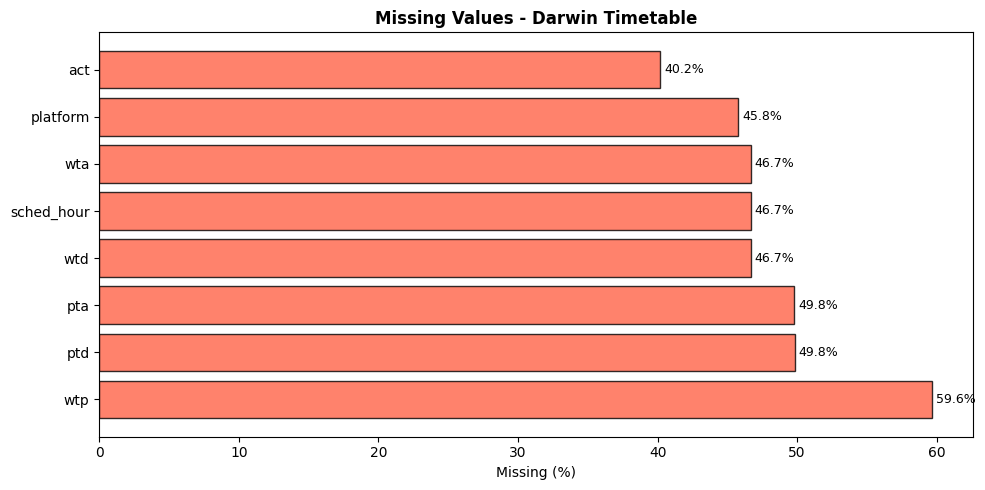

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_nz = missing[missing["missing_pct"] > 0]
if len(missing_nz):
    ax.barh(missing_nz.index, missing_nz["missing_pct"],
            color="tomato", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    for i, v in enumerate(missing_nz["missing_pct"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
ax.set_title("Missing Values - Darwin Timetable", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/eda_04/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

Time field coverage:
     non_null  pct_present
wta   5345898        53.33
wtd   5345792        53.33
wtp   4044270        40.35
pta   5035102        50.23
ptd   5029743        50.18


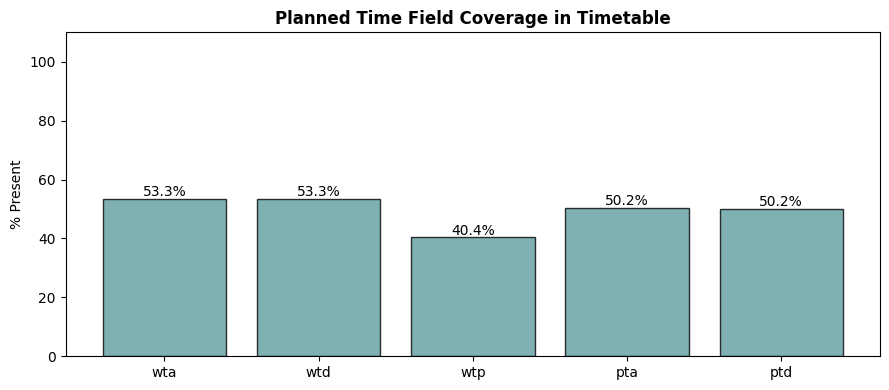

In [9]:
# wta = working time arrival, wtd = working time departure (operational precision)
# pta = public time arrival, ptd = public time departure (passenger-facing, rounded)
# wtp = working time pass (non-stopping locations)
# Coverage determines which stop rows have usable scheduled timestamps

time_cols = [c for c in ["wta", "wtd", "wtp", "pta", "ptd"]
             if c in timetable_df.columns]

coverage = pd.DataFrame({
    "non_null":    [timetable_df[c].notna().sum() for c in time_cols],
    "pct_present": [timetable_df[c].notna().mean() * 100 for c in time_cols],
}, index=time_cols).round(2)

print("Time field coverage:")
print(coverage.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(coverage.index, coverage["pct_present"],
       color="cadetblue", edgecolor="black", alpha=0.8)
ax.set_ylabel("% Present")
ax.set_title("Planned Time Field Coverage in Timetable", fontweight="bold")
ax.set_ylim(0, 110)
for i, v in enumerate(coverage["pct_present"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("figures/eda_04/time_field_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Stop Type Distribution

In [10]:
STOP_TYPE_MAP = {
    "OR":   "Origin",
    "OPOR": "Origin (optional)",
    "IP":   "Intermediate stop",
    "OPIP": "Intermediate (optional pass)",
    "PP":   "Passing point",
    "DT":   "Destination",
    "OPDT": "Destination (optional)",
}

if "stop_type" in timetable_df.columns:
    st_counts = timetable_df["stop_type"].value_counts()
    print("Stop type distribution:")
    for k, v in st_counts.items():
        label = STOP_TYPE_MAP.get(k, k)
        print(f"  {k:6s} ({label:35s}): {v:,} ({v/len(timetable_df)*100:.1f}%)")

Stop type distribution:
  IP     (Intermediate stop                  ): 4,550,572 (45.4%)
  PP     (Passing point                      ): 4,044,270 (40.3%)
  DT     (Destination                        ): 493,728 (4.9%)
  OR     (Origin                             ): 493,647 (4.9%)
  OPIP   (Intermediate (optional pass)       ): 161,925 (1.6%)
  OPDT   (Destination (optional)             ): 139,673 (1.4%)
  OPOR   (Origin (optional)                  ): 139,648 (1.4%)


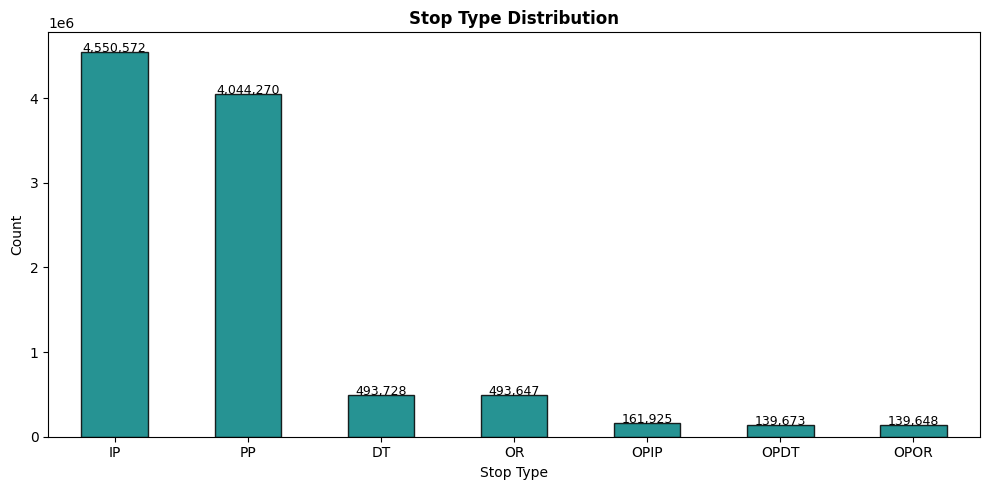

In [11]:
if "stop_type" in timetable_df.columns:
    plt.figure(figsize=(10, 5))
    st_counts.plot(kind="bar", color="teal", edgecolor="black", alpha=0.85)
    plt.xlabel("Stop Type")
    plt.ylabel("Count")
    plt.title("Stop Type Distribution", fontweight="bold")
    plt.tick_params(axis="x", rotation=0)
    for i, v in enumerate(st_counts.values):
        plt.text(i, v + 50, f"{v:,}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_04/stop_type.png", dpi=200, bbox_inches="tight")
    plt.show()

## 5. TOC (Train Operating Company) Distribution

In [12]:
if "toc" in timetable_df.columns:
    # Journey-level deduplication - one row per rid
    journey_toc = (
        timetable_df
        .drop_duplicates(subset=["rid"])["toc"]
        .value_counts()
    )
    print(f"Unique TOCs: {len(journey_toc)}")
    print()
    print("Journeys per TOC:")
    print(journey_toc.to_string())

Unique TOCs: 42

Journeys per TOC:
toc
SR    71681
NT    65000
GW    50242
SW    47705
SE    44537
SN    42179
LO    34260
LE    32331
AW    29671
LM    29144
TL    24592
XR    23882
LT    20234
EM    14862
ME    14400
TP    11708
GN    11391
VT    10384
CC    10273
XC    10202
CH     9441
GR     8637
TW     3338
HX     3092
SJ     1675
GX     1513
ZZ     1391
ES     1196
IL     1022
GC      628
HT      530
CS      521
LD      440
WR      359
LF      279
LS      181
TY       78
MV       50
NY       34
SO       17
PX        2
YG        1


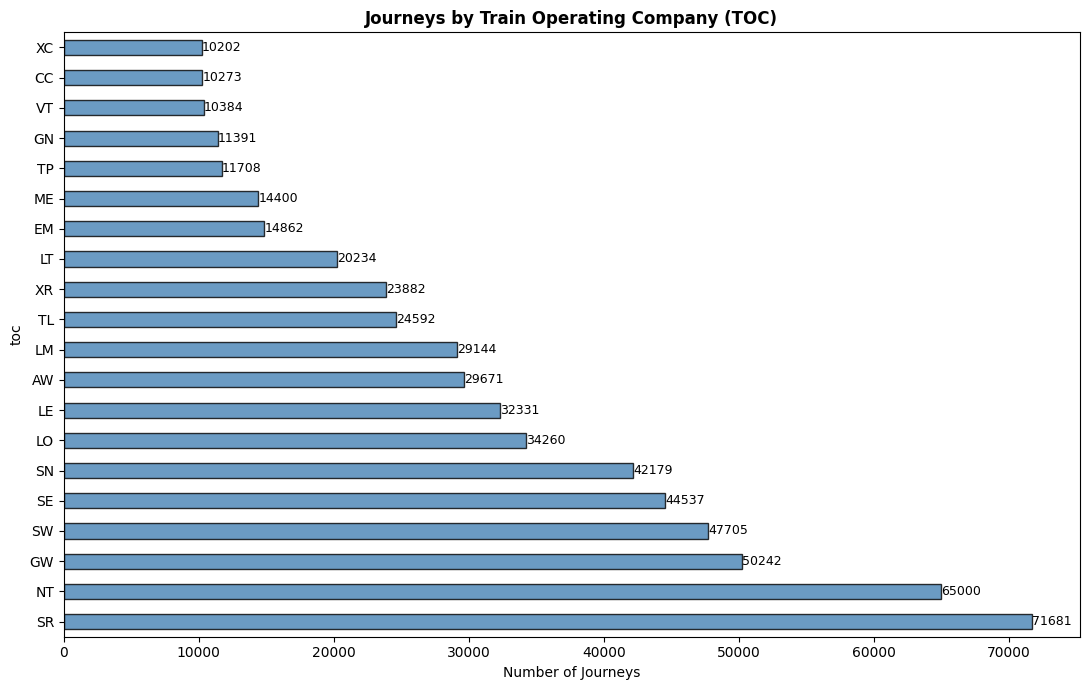

In [13]:
if "toc" in timetable_df.columns:
    journey_toc.head(20).plot(
        kind="barh", color="steelblue", edgecolor="black",
        alpha=0.8, figsize=(11, 7)
    )
    plt.xlabel("Number of Journeys")
    plt.title("Journeys by Train Operating Company (TOC)", fontweight="bold")
    for i, v in enumerate(journey_toc.head(20).values):
        plt.text(v + 2, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_04/toc_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

## 6. Service Date Coverage

Stop rows by service date:
ssd
2026-04-09      6020
2026-04-10    542691
2026-04-11    489775
2026-04-12    313474
2026-04-13    539526
2026-04-14    543424
2026-04-15    542923
2026-04-16    542898
2026-04-17    541952
2026-04-18    475056
2026-04-19    307657
2026-04-20    543983
2026-04-21    546569
2026-04-22    546545
2026-04-23    547090
2026-04-24    547031
2026-04-25    488583
2026-04-26    318438
2026-04-27    544254
2026-04-28    546112
2026-04-29    543930
2026-04-30      5532

Unique journeys by service date:
ssd
2026-04-09      527
2026-04-10    32930
2026-04-11    31477
2026-04-12    21986
2026-04-13    33324
2026-04-14    33765
2026-04-15    33783
2026-04-16    33775
2026-04-17    33640
2026-04-18    31814
2026-04-19    22761
2026-04-20    33301
2026-04-21    33738
2026-04-22    33717
2026-04-23    33734
2026-04-24    33533
2026-04-25    31874
2026-04-26    21975
2026-04-27    33245
2026-04-28    33664
2026-04-29    33705
2026-04-30      835


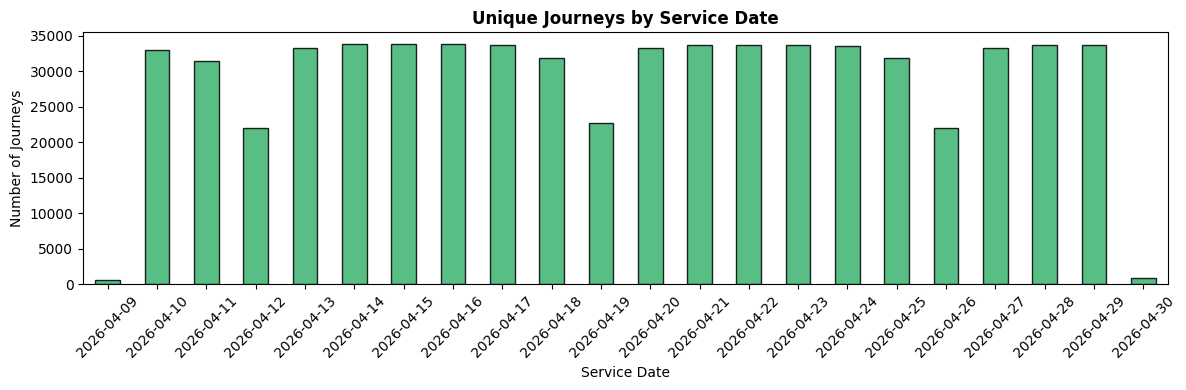

In [14]:
if "ssd" in timetable_df.columns:
    date_counts = timetable_df["ssd"].value_counts().sort_index()
    print("Stop rows by service date:")
    print(date_counts.to_string())
    print()

    journey_dates = (
        timetable_df
        .drop_duplicates(subset=["rid"])["ssd"]
        .value_counts()
        .sort_index()
    )
    print("Unique journeys by service date:")
    print(journey_dates.to_string())

    fig, ax = plt.subplots(figsize=(12, 4))
    journey_dates.plot(kind="bar", ax=ax, color="mediumseagreen",
                       edgecolor="black", alpha=0.85)
    ax.set_xlabel("Service Date")
    ax.set_ylabel("Number of Journeys")
    ax.set_title("Unique Journeys by Service Date", fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig("figures/eda_04/service_date_coverage.png", dpi=200, bbox_inches="tight")
    plt.show()

## 7. Service Frequency by Hour

Scheduled stop rows by hour:
sched_hour
0      78168
1      17984
2       5047
3       4097
4      18605
5     101339
6     246349
7     300027
8     307650
9     301991
10    292037
11    289812
12    288162
13    288175
14    289249
15    295703
16    307990
17    320887
18    318593
19    299039
20    274478
21    259681
22    241407
23    199322


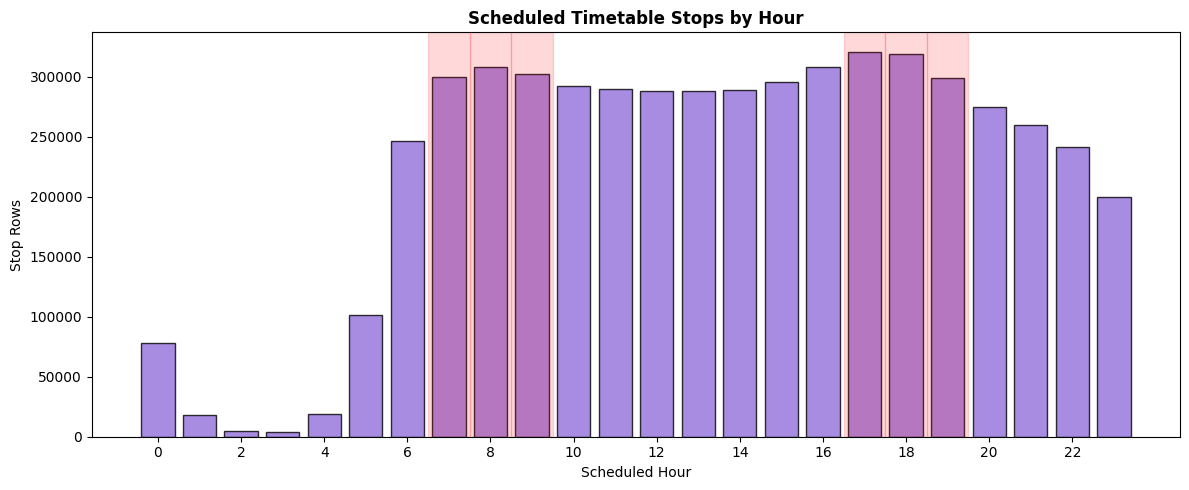

In [15]:
# sched_hour is created during preprocessing and reused here.
hour_counts = (
    timetable_df["sched_hour"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

print("Scheduled stop rows by hour:")
print(hour_counts.to_string())

plt.figure(figsize=(12, 5))
plt.bar(hour_counts.index, hour_counts.values,
        color="mediumpurple", edgecolor="black", alpha=0.8)
for h in list(range(7, 10)) + list(range(17, 20)):
    plt.axvspan(h - 0.5, h + 0.5, alpha=0.15, color="red")
plt.xlabel("Scheduled Hour")
plt.ylabel("Stop Rows")
plt.title("Scheduled Timetable Stops by Hour", fontweight="bold")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.savefig("figures/eda_04/scheduled_hour_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Stops per Journey

Stops per journey statistics:
count    633103.0
mean         15.8
std          13.1
min           2.0
25%           5.0
50%          14.0
75%          22.0
max         151.0
dtype: float64

Journeys with 1 stop:      0
Journeys with 2-5 stops:   173,714
Journeys with 6-15 stops:  166,669
Journeys with > 15 stops:  292,720


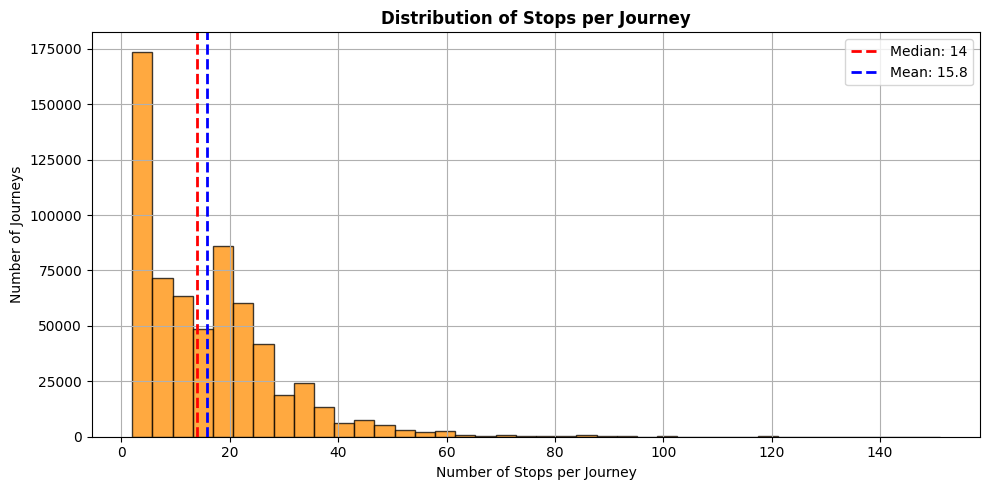

In [16]:
if "rid" in timetable_df.columns:
    stops_per_journey = timetable_df.groupby("rid").size()

    print("Stops per journey statistics:")
    print(stops_per_journey.describe().round(1))
    print()
    print(f"Journeys with 1 stop:      {(stops_per_journey == 1).sum():,}")
    print(f"Journeys with 2-5 stops:   {((stops_per_journey >= 2) & (stops_per_journey <= 5)).sum():,}")
    print(f"Journeys with 6-15 stops:  {((stops_per_journey >= 6) & (stops_per_journey <= 15)).sum():,}")
    print(f"Journeys with > 15 stops:  {(stops_per_journey > 15).sum():,}")

    plt.figure(figsize=(10, 5))
    stops_per_journey.hist(bins=40, edgecolor="black", alpha=0.75,
                           color="darkorange")
    plt.axvline(stops_per_journey.median(), color="red", linestyle="--",
                lw=2, label=f"Median: {stops_per_journey.median():.0f}")
    plt.axvline(stops_per_journey.mean(), color="blue", linestyle="--",
                lw=2, label=f"Mean: {stops_per_journey.mean():.1f}")
    plt.xlabel("Number of Stops per Journey")
    plt.ylabel("Number of Journeys")
    plt.title("Distribution of Stops per Journey", fontweight="bold")
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/eda_04/stops_per_journey.png", dpi=200, bbox_inches="tight")
    plt.show()

## 8. TIPLOC Match Rate Against Stations Reference

The TIPLOC code links each timetable stop to the stations reference. Match rate determines how many scheduled stops can be spatially joined to nearby road closures in EDA 06.

In [17]:
if "tpl" in timetable_df.columns and "tiploc" in stations_reference_df.columns:
    timetable_tpls = set(timetable_df["tpl"].dropna().str.strip().str.upper())
    reference_tpls = set(
        stations_reference_df["tiploc"].dropna().str.strip().str.upper()
    )
    matched   = timetable_tpls & reference_tpls
    unmatched = timetable_tpls - reference_tpls

    print(f"Unique TPLs in timetable:      {len(timetable_tpls):,}")
    print(f"TIPLOC codes in reference:     {len(reference_tpls):,}")
    print(f"Matched:                       {len(matched):,} ({len(matched)/len(timetable_tpls)*100:.1f}%)")
    print(f"Unmatched (timetable only):    {len(unmatched):,}")

    row_match = timetable_df["tpl"].str.strip().str.upper().isin(reference_tpls)
    print(f"\nStop rows with matched TIPLOC: {row_match.sum():,} ({row_match.mean()*100:.1f}%)")
    print(f"Stop rows without match:       {(~row_match).sum():,} ({(~row_match).mean()*100:.1f}%)")

    print(f"\nSample unmatched TIPLOCs (junctions, depots, waypoints):")
    print(sorted(unmatched)[:20])

Unique TPLs in timetable:      5,160
TIPLOC codes in reference:     2,594
Matched:                       2,583 (50.1%)
Unmatched (timetable only):    2,577

Stop rows with matched TIPLOC: 6,163,055 (61.5%)
Stop rows without match:       3,860,408 (38.5%)

Sample unmatched TIPLOCs (junctions, depots, waypoints):
['ABARASQ', 'ABCWM', 'ABDARAR', 'ABHLJN', 'ABINGTN', 'ABRBEG', 'ABRD222', 'ABRD223', 'ABRD229', 'ABRD230', 'ABRD27', 'ABRD55', 'ABRD56', 'ABRD77', 'ABRDCH', 'ABRDFGL', 'ABRDFJN', 'ABRDFTT', 'ABRGS38', 'ABTH']


## 9. Save Output

The cleaned timetable Parquet was saved before EDA. This final section checks the saved dataframe structure.

In [18]:
print(f"Already saved before EDA: darwin_timetable_clean.parquet - {len(timetable_df):,} rows")
print(f"Unique journeys:  {timetable_df['rid'].nunique():,}")
print(f"Unique TIPLOCs:   {timetable_df['tpl'].nunique():,}")
print(f"Date range:       {timetable_df['planned_date'].min()} to {timetable_df['planned_date'].max()}")
print("\nColumns available:")
timetable_df.info()


Already saved before EDA: darwin_timetable_clean.parquet - 10,023,463 rows
Unique journeys:  633,103
Unique TIPLOCs:   5,160
Date range:       2026-04-09 00:00:00 to 2026-04-30 00:00:00

Columns available:
<class 'pandas.DataFrame'>
Index: 10023463 entries, 956632 to 18105039
Data columns (total 21 columns):
 #   Column        Dtype        
---  ------        -----        
 0   rid           str          
 1   uid           str          
 2   trainId       str          
 3   ssd           object       
 4   toc           str          
 5   stop_type     str          
 6   tpl           str          
 7   platform      str          
 8   act           str          
 9   pta           str          
 10  ptd           str          
 11  wta           str          
 12  wtd           str          
 13  wtp           str          
 14  planned_date  datetime64[s]
 15  day_of_week   int32        
 16  is_weekend    int64        
 17  is_monday     int64        
 18  is_friday     int64      